### Configuration

This notebook reads MongoDB credentials from the `MONGO_URI` environment variable. Set it before launching Jupyter and do not paste credentials into notebook cells.


In [1]:
import os

mongo_uri = os.environ.get("MONGO_URI")
if not mongo_uri:
    raise RuntimeError("Set MONGO_URI before running this notebook.")

from episcope.db.mongo_academic_db import MongoAcademicDB
strategy_name="grobid"
db = MongoAcademicDB(
    uri=mongo_uri,
    db_name="episcope_academic_db",
)
len(db.list_docs(strategy_name=strategy_name))

2298

In [2]:
from episcope.vectordb.qdrant import QdrantDB
vdb = QdrantDB(
    collection="episcope_academic_vdb2", 
    # dim=emb.dim, 
    url="http://localhost:6334")

INFO:httpx:HTTP Request: GET http://localhost:6334 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET http://localhost:6334/collections/episcope_academic_vdb2 "HTTP/1.1 200 OK"


In [3]:
import pandas as pd
df = pd.read_csv("sampled_papers_full.csv", sep=";")
all_docs = df.paper_id.tolist()

In [4]:
# all_docs = db.list_docs(strategy_name=strategy_name)

In [5]:
from episcope.rag.retrieval.semantic import SemanticRetriever
retriever = SemanticRetriever(vdb)

INFO:datasets:PyTorch version 2.6.0 available.
INFO:datasets:Polars version 1.34.0 available.
INFO:httpx:HTTP Request: POST http://localhost:6334/collections/episcope_academic_vdb2/points/scroll "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:6334/collections/episcope_academic_vdb2/points/scroll "HTTP/1.1 200 OK"
INFO:episcope.rag.retrieval.semantic:VectorDB is configured with embedding model: 'gemini-embedding-001'. Instantiating corresponding embedder for retrieval.
INFO:episcope.rag.embeddings.factory:Detected Gemini model 'gemini-embedding-001'. Creating GeminiEmbedder.
E0000 00:00:1771689960.273527 53221871 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [6]:
# from episcope.rag.generation.llm_generator import LLMGenerator
# generator = LLMGenerator(model="qwen2.5vl:3b") # "qwen2.5vl:3b"

from episcope.clients import GeminiClient
from episcope.rag.generation.llm_generator import LLMGenerator
client = GeminiClient()
generator = LLMGenerator(client=client, model="gemini-2.5-pro")

In [7]:
from episcope.workflows import PaperClassifier
from episcope.workflows.classification import DataAccessibilityClassifierConfig, DataTypeClassifierConfig, PaperTypeClassifierConfig
classifier = PaperClassifier(
    retriever=retriever,
    generator=generator,
    academic_db=db,
    strategy_name=strategy_name,
    config=DataTypeClassifierConfig()
)

In [8]:
paper_id = "10.1093/ofid/ofw172.531"
classifier.run(paper_id)

E0000 00:00:1771689960.728528 53221871 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.
INFO:httpx:HTTP Request: POST http://localhost:6334/collections/episcope_academic_vdb2/points/search "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:6334/collections/episcope_academic_vdb2/points/search "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:6334/collections/episcope_academic_vdb2/points/search "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:6334/collections/episcope_academic_vdb2/points/search "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:6334/collections/episcope_academic_vdb2/points/search "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:6334/collections/episcope_academic_vdb2/points/search "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:6334/collections/episcope_academic_vdb2/points/search "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST 

ClassificationResult(classification=[<DataType.TRADITIONAL: 'traditional'>], confidence=1.0, class_probabilities={'A': 1.0, 'B': 0.0, 'C': 0.0, 'D': 0.0, 'E': 0.0, 'F': 0.0, 'G': 0.0, 'H': 0.0}, evidence={'reasoning': 'The study is a retrospective analysis of data from 543 hospitalized patients. The data used for analysis includes demographic, epidemiological, clinical characteristics, laboratory data, and treatment outcomes, all of which are standard forms of traditional clinical and administrative health data.'}, extras={})

In [ ]:
# import pandas as pd
df_results_disk = pd.read_csv("DATA_TYPE_sample.csv")

In [ ]:
import pandas as pd
list_results = []

for paper_id in all_docs:# [1:2]:
    if paper_id in df_results_disk.paper_id.unique():
        print(f"skipping paper {paper_id} because it has already been analyzed")
        continue
    c_res = classifier.run(paper_id)
    result = {
    "paper_id": paper_id,
    "classification": [c.name for c in c_res.classification],
    "class_probabilities": c_res.class_probabilities,
    "confidence": c_res.confidence,
    "evidence": c_res.evidence["reasoning"]
    }
    list_results.append(result)




In [ ]:
# pd.set_option('display.max_colwidth', None)


df_results = pd.DataFrame(list_results)
len(df_results)

In [ ]:
len(df_results_disk)

In [ ]:
# df_results.to_csv("DATA_TYPE_sample.csv")

In [ ]:
df_results_new = pd.concat([df_results_disk,df_results])

In [ ]:
# remove Unnamend: 0 column if exists
if "Unnamed: 0" in df_results_new.columns:
    df_results_new = df_results_new.drop(columns=["Unnamed: 0"])

In [ ]:
#reindex
df_results_new = df_results_new.reset_index(drop=True)

In [ ]:
df_results_new

In [ ]:
# # save df_results on disk
# df_results_new.to_csv("DATA_TYPE_C1.csv")

In [ ]:
# df_results.to_csv("CLASSIFICATION_MODEL_NO_SNIPPETS.csv", index=False)

In [ ]:
# c_res.confidence

## Analysis

In [16]:
import pandas as pd
import ast

df_analysis = pd.read_csv("output_full/data-type/gemini-2-5-flash/temperature_0.0/grobid/episcope-academic-vdb2-feb7cff561cd/final_1.tsv", index_col=False, sep="\t")
# removing the failed runs - Classification failed
df_analysis = df_analysis[["failed" not in txt_evidence for txt_evidence in df_analysis['evidence'].values]]

In [17]:
# df_analysis[df_analysis['classification'].apply(lambda x: "UNCLEAR" in eval(x))]

In [18]:
# pd.set_option('display.max_colwidth', None)
# df_analysis

In [19]:
n_papers = len(df_analysis)
n_papers

2297

In [20]:
entries = [data_type for data_types_list in df_analysis.classification.values for data_type in eval(data_types_list)]

In [21]:
from collections import Counter
c = Counter(entries)

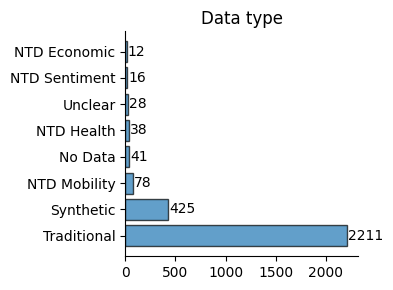

In [28]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd


class_to_label = {
    'TRADITIONAL': "Traditional",
         'NON_TRADITIONAL_HEALTH': "NTD Health",
         'SYNTHETIC': "Synthetic",
         'NO_EMPIRICAL_DATA': "No Data",
         'NON_TRADITIONAL_MOBILITY': "NTD Mobility",
         'UNCLEAR': "Unclear",
         'NON_TRADITIONAL_ECONOMIC': "NTD Economic",
         'NON_TRADITIONAL_SENTIMENT': "NTD Sentiment"
         }

# Convert to a pandas Series for easy sorting and plotting
data_series = pd.Series(c).sort_values(ascending=False)

# Create the figure and axes
plt.figure(figsize=(4, 3))
bars = plt.barh(
    [class_to_label[i] for i in data_series.index], 
    data_series.values,
    edgecolor='black', 
    alpha=0.7
)

# Apply specific styles to "Unclear", "No Data", and "Synthetic"
for bar, label in zip(bars, data_series.index):
    if label in []:#['UNCLEAR']:# , 'NO_EMPIRICAL_DATA', 'SYNTHETIC']:
        bar.set_color('gray')  # Gray out the bars
        bar.set_hatch('//')    # Add a hatch pattern for better distinction

# Set title and labels
plt.title('Data type', fontsize=12, pad=5)
# plt.xlabel('Proportion', fontsize=12)
# plt.ylabel('Availability', fontsize=12)

# Format the x-axis as percentages
# plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Add value labels to the end of each bar for clarity
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10,  # Position x-coordinate
             bar.get_y() + bar.get_height() / 2,  # Position y-coordinate
             f'{width:}',  
             ha='left',  # Horizontal alignment
             va='center',  # Vertical alignment
             fontsize=10)

# Remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Ensure the layout is clean
plt.tight_layout()

# Save the plot to a file
plt.savefig("DataType_proportions.pdf")

# print("Generated professional_proportions_chart.png")


In [23]:
n_papers = len(df_analysis)
c_frac = {k:v/n_papers for k,v in c.items()}
c_frac

{'TRADITIONAL': 0.9625598606878537,
 'NON_TRADITIONAL_MOBILITY': 0.03395733565520244,
 'SYNTHETIC': 0.1850239442751415,
 'NON_TRADITIONAL_ECONOMIC': 0.00522420548541576,
 'NON_TRADITIONAL_HEALTH': 0.01654331737048324,
 'NO_EMPIRICAL_DATA': 0.01784936874183718,
 'NON_TRADITIONAL_SENTIMENT': 0.006965607313887679,
 'UNCLEAR': 0.012189812799303439}

### NTDs breackdown

In [12]:

from collections import Counter
import matplotlib.pyplot as plt

def plot_counter_data(counter_data, threshold=5, title="Continent", xlabel="", ylabel="Frequency"):
    """
    Plots a bar chart for a Counter dictionary, grouping smaller values into an "Others" bin.

    Parameters:
        counter_data (Counter): The Counter dictionary to plot.
        threshold (int): The minimum frequency for an item to be displayed individually.
        title (str): The title of the plot.
        xlabel (str): The label for the x-axis.
        ylabel (str): The label for the y-axis.
    """
    # Sort the Counter dictionary by frequency
    sorted_data = counter_data.most_common()

    # Group smaller values into an "Others" bin
    grouped_data = Counter({k: v for k, v in sorted_data if v >= threshold})
    others_count = sum(v for k, v in sorted_data if v < threshold)
    if others_count > 0:
        grouped_data["Others"] = others_count

    # Create the bar plot
    plt.figure(figsize=(6, 4))
    plt.bar(grouped_data.keys(), grouped_data.values(), edgecolor='black', alpha = .7)

    # Add labels and title
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right', fontsize=10)

    # Display the plot
    plt.tight_layout()
    # plt.show()

In [13]:
ntd_entries = [e for e in entries if "NON_TRADITIONAL" in e]
c_ntd = Counter(ntd_entries)
c_ntd = Counter({class_to_label[k].replace("NTD","").strip(): v for k, v in c_ntd.items()})

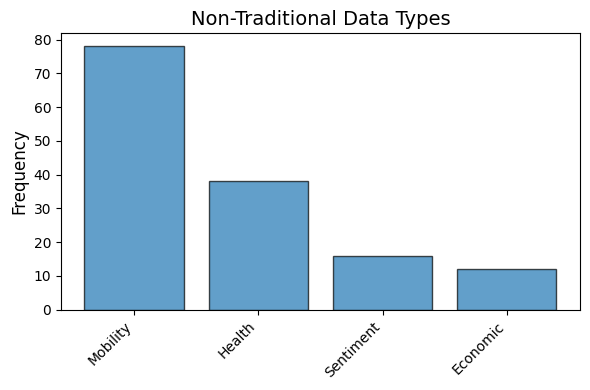

In [14]:
plot_counter_data(c_ntd, threshold=5, title="Non-Traditional Data Types")
plt.savefig("DataType_NTD.pdf")

